# Helium Tests
#### Contour Generation and Plotting - 11/03/2025
###### Hypersonic Nozzle - Senior Design Fall 2025 - Dr. Nicholaus Parziale
###### Lucas Brusa-O'Connell (lbrusaoc@stevens.edu)

Dependancies:
    - numpy
    - matplotlib
    - scipy
    - jupyter notebook
Pandas is required to use ConturTable.to_pandas() but not implemented in this example.

ConturSettings provides a class-based interface to create input cards for Contur and ConturApplication provides the runtime and results for the compiled Contur executable. 

In [37]:
from conturpy import ConturSettings, ConturApplication

import matplotlib
#matplotlib.use('Agg')  # Non-interactive backend, does not display figures
import matplotlib.pyplot as plt

First, we must create the input parameters for Contur. 
Below, input cards are defined using various parameters. Each contains a description besides it for convenience.

In [38]:
c = ConturSettings()


throat_radius = 0.15/2 # inches

dmach = 11               # design mach

# Card 1: the title of the simulation
c["ITLE"] = f"Mach {dmach}"
c["JD"] = -1         # Axisymmetric or planar nozzle. Set to 0 for axisymmetric or -1 for planar nozzle.


# Card 2 contains gas properties. As air is the assumed working fluid, no changes are required
# All properties taken from sutherlands code
c["GAM"] = 1.667      # Ratio of specific heats.
c["AR"] = 12421.933   # Gas constant in ft^2/sec^2 * R [or ft*lbf/(slug*R)]
c["ZO"] = 1.0         # Compressability factor for axisymmetric nozzle. Untested: half distance (in) between walls and assumed compressability factor of 1
c["RO"] = 0.872       # Turbulent boundary layer recovery factor (see Sivells' paper)
# Sutherlands Law has a 25% error at 50K, 8.8% error at 100K, and 2% error 200-600K. The law is much more accurate at higher temperatures, which is bad since our nozzle continuously decreases the temperature
c["VISC"]= 2.170E-08  # b: Constant in viscosity law (see Sivells' paper) [in lbf * s / (ft^2 * R^1/2)]
# VISC appears to be the sutherland constant as calculate by NACA on pg22 of Sivells
c["VISM"] = 96.956    # S: Sutherland temperature in Rankine
# VISM might be a lowerbound cutoff temperature for sutherland law instead: "Viscocity follows sutherlands law above VISM, but is linear with temperature below VISM" Sivells' paper pg64
c["SFOA"] = 0         # If zero: 3rd or 4th degree velocity distribution depending on IX. If negative: absolute value is distance from throat to point G (see Sivells' paper). If positive: distance from throat to point A (see Sivells' paper).
#c["XBL"] = 1000      # Where to start interpolating. If 1000, use spline fit to get evenly spaced points on wall contour.


# Card 3: key design parameters
c["ETAD"] = 60        # Angle at point D. Inflection angle for radial flow. If ETAD=60, the entire centerline velocity distribution is specified; IQ=1 and IX=0 on card 4.
print((0.5)/throat_radius * 6)
c["RC"] = 0.5/throat_radius * 6         # The radius of curvature of the throat: multiples of throat radius. [Suggest in the neighborhood of 5.5-6.0]
c["FMACH"] = 0        # If ETAD is not 60, Mach number at point F (see Sivells' paper)
c["BMACH"] = 0        # If ETAD is not 60, Mach number at point B (see Sivells' paper)
c["CMC"] = dmach      # The design mach number at point C (see Sivells' paper). This should be the design mach number of the nozzle. If ETAD is not 0, check Sivells' paper as this parameter is important.
c["SF"] = throat_radius # If positive, the nozzle has this as the throat radius (or half height) in inches. If 0, the nozzle has radius (or half height) 1 inch. If negative, the nozzle has this as the exit radius (or half height) in inches.
#c["PP"] = 0          # Location of point A (see Sivells' paper). Strongly suggest setting to 0 (driven dimension) unless user is positive they want to specify location A.
#c["XC"] = 0          # Nondimensional distance from radial source to point C (see Sivells' paper). Suggest 0 (4th degree velocity distribution).

# # Card 4: 
# c["MT"] = 81	    #Number of points on characteristic CD if ETAD=60 or EG if ETAD is not 60 (see Sivells' paper). Must be odd.
# c["NT"] = 41	    # Number of points on axis IE (see Sivells' paper). Make sure abs(LR) + abs(NT) extless{}= 149. Must be odd.
# c["IX"] = 0	# Unsure.
# c["IN"] = 10	    # If nonzero, the downstream value of the second derivative of velocity at point B is 0.1 * IN times the transonic value if ETAD=60 or 0.1 * abs(IN) times the radial value if ETAD is not 60. Use 0 for throat only. Suggest 10.
# c["IQ"] = 0	    # If ETAD is not 60, 0 for complete contour, 1 for throat only, and -1 for downstream only.
# c["MD"] = 61	    # Number of points on characteristic AB (see Sivells' paper). No more than 125. Must be odd.
# c["ND"] = 69	    # Number of points on axis BC (see Sivells' paper). No more than 150.
# c["NF"] = -61	    # Number of points on characteristic CD if ETAD is not 60. See Sivells' paper if using.
# c["MP"] = 0	    # Number of points on section GA (see Sivells' paper) if FMACH is not equal to BMACH. Sivells notes "Usually not known for initial calculation"
# c["MQ"] = 0	    # Number of points downstream of point D if parallel contour desired. Negative to stop inviscid printout.
# c["JB"] = 1	    # If positive: number of boundary layer calculations before spline fit. Negative impact is unknown, see Sivells' paper. Suggest 1.
# c["JX"] = 0	    # Positive calculates streamlines. If XBL = 1000, spline fit after invisid calculation if JX=0 or repeat of calculation if negative. If XBL is not 1000, repeat calculations.
# c["JC"] = 1	    # If not zero, print out inviscid characteristics for every JC characteristic. Positive for upstream and negative for downstream.
# c["IT"] = 0	# Unsure.
# c["LR"] = -25	    # Number of points on throat characteristic. Negative prints out transonic solution. If 0, M=1 at point I. See NT.
# c["NX"] = 13	    # Logarithmic spacing for upstream contour. 10 is closer spacing and 20 is further spacing. Between 10 or 20. Suggest 13.

# # Card 5: 
# c["NOUP"] = 50	# Unsure.
# c["NPCT"] = 85	# Unsure.
# c["NODO"] = 50	# Unsure.


# Card 6 (B): stagnation and heat transfer properties
# 290 psi and 900R for Parziale
c["PPQ"] = 290      # Stagnation pressure [psia] (unkown breaking point) #120 starting
c["TO"] = 1200      # Stagnation temperature [R] (breaks at 1219: investigate) #1000 starting
c["TWT"] = 540      # Wall temperature [R]
c["TWAT"] = 540     # Water-cooling temp [R] (suggest setting to TWT since water cooling not assumed)


# Card 7 (D): interpolation parameters
c["XLOW"] = 0       # Point to begin interpolating contour [in]
c["XEND"] = 80      # Point to end interpolating contour [in]
c["XINC"] = .08      # Increment to interpolate by [in]

# Create the input text file and save it to 'm5.0.txt' in the folder 'inputcards'
c.print_to_input(file_name=f'm{dmach:.1f}.txt', output_directory='inputcards')

40.0


___
Comment on gas properties for air:
using the coolprop fit, the following results were obtained -

>SI Units
>
>b_He: 1.4670364811443242×10⁻⁶ Pa·s/K⁰⋅⁵
>
>S_He: 110.38768748531741 K
>
>Imperial Units
>
>b_He: 2.283747948995038×10⁻⁸ lbf·s/°R⁰⋅⁵/ft²
>
>S_He: 198.69783747357133 °R

Extremely good fit for air for the range 100-400K at 1atm. In very good aggreement with [ANSYS](https://www.afs.enea.it/project/neptunius/docs/fluent/html/ug/node294.htm#eq-viscosity-suth2) and [Tables of Thermal Properties of Gases (p.10)](https://nvlpubs.nist.gov/nistpubs/Legacy/circ/nbscircular564.pdf)

HOWEVER, helium has a famously bad fit with Sutherlands law at low temperatures 
___

Next, initialize and run the Contur executable for all files in the 'inputcards' folder and send all outputs to the 'outputs' folder. All files used as inputs are automatically removed. A ConturResults instance is created for every input and returned.

Contur's boundary layer output is unusual and the author could not figure out how to treat this subsection. Attempting to read boundary layer output will often throw a warning about un-formatted extra Contur array outputs, but this is fine as no data is lost.

In [39]:
ca = ConturApplication()
res = ca.batch_input_folder('inputcards', output_dir='outputs')


Lastly, for every ConturResult, save plots and data in .csv files to a subfolder under the 'outputs' folder titled 'nozzle_5.0/'

The cell starts with %%capture to prevent drawing of half-finished plots

In [40]:
%%capture

for r in res:
    r.save_all(f"outputs/nozzle_{r.design_mach}")
    

# edited conturpy\plot_results.py
# lines 52, 88, 114, 158, and 184
# changed noz_y_rng = noz_y.ptp() ---> noz_y_rng = np.ptp(noz_y)
# AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.
# reason: we are using numpy 2.2.6

Plot all plots within the notebook

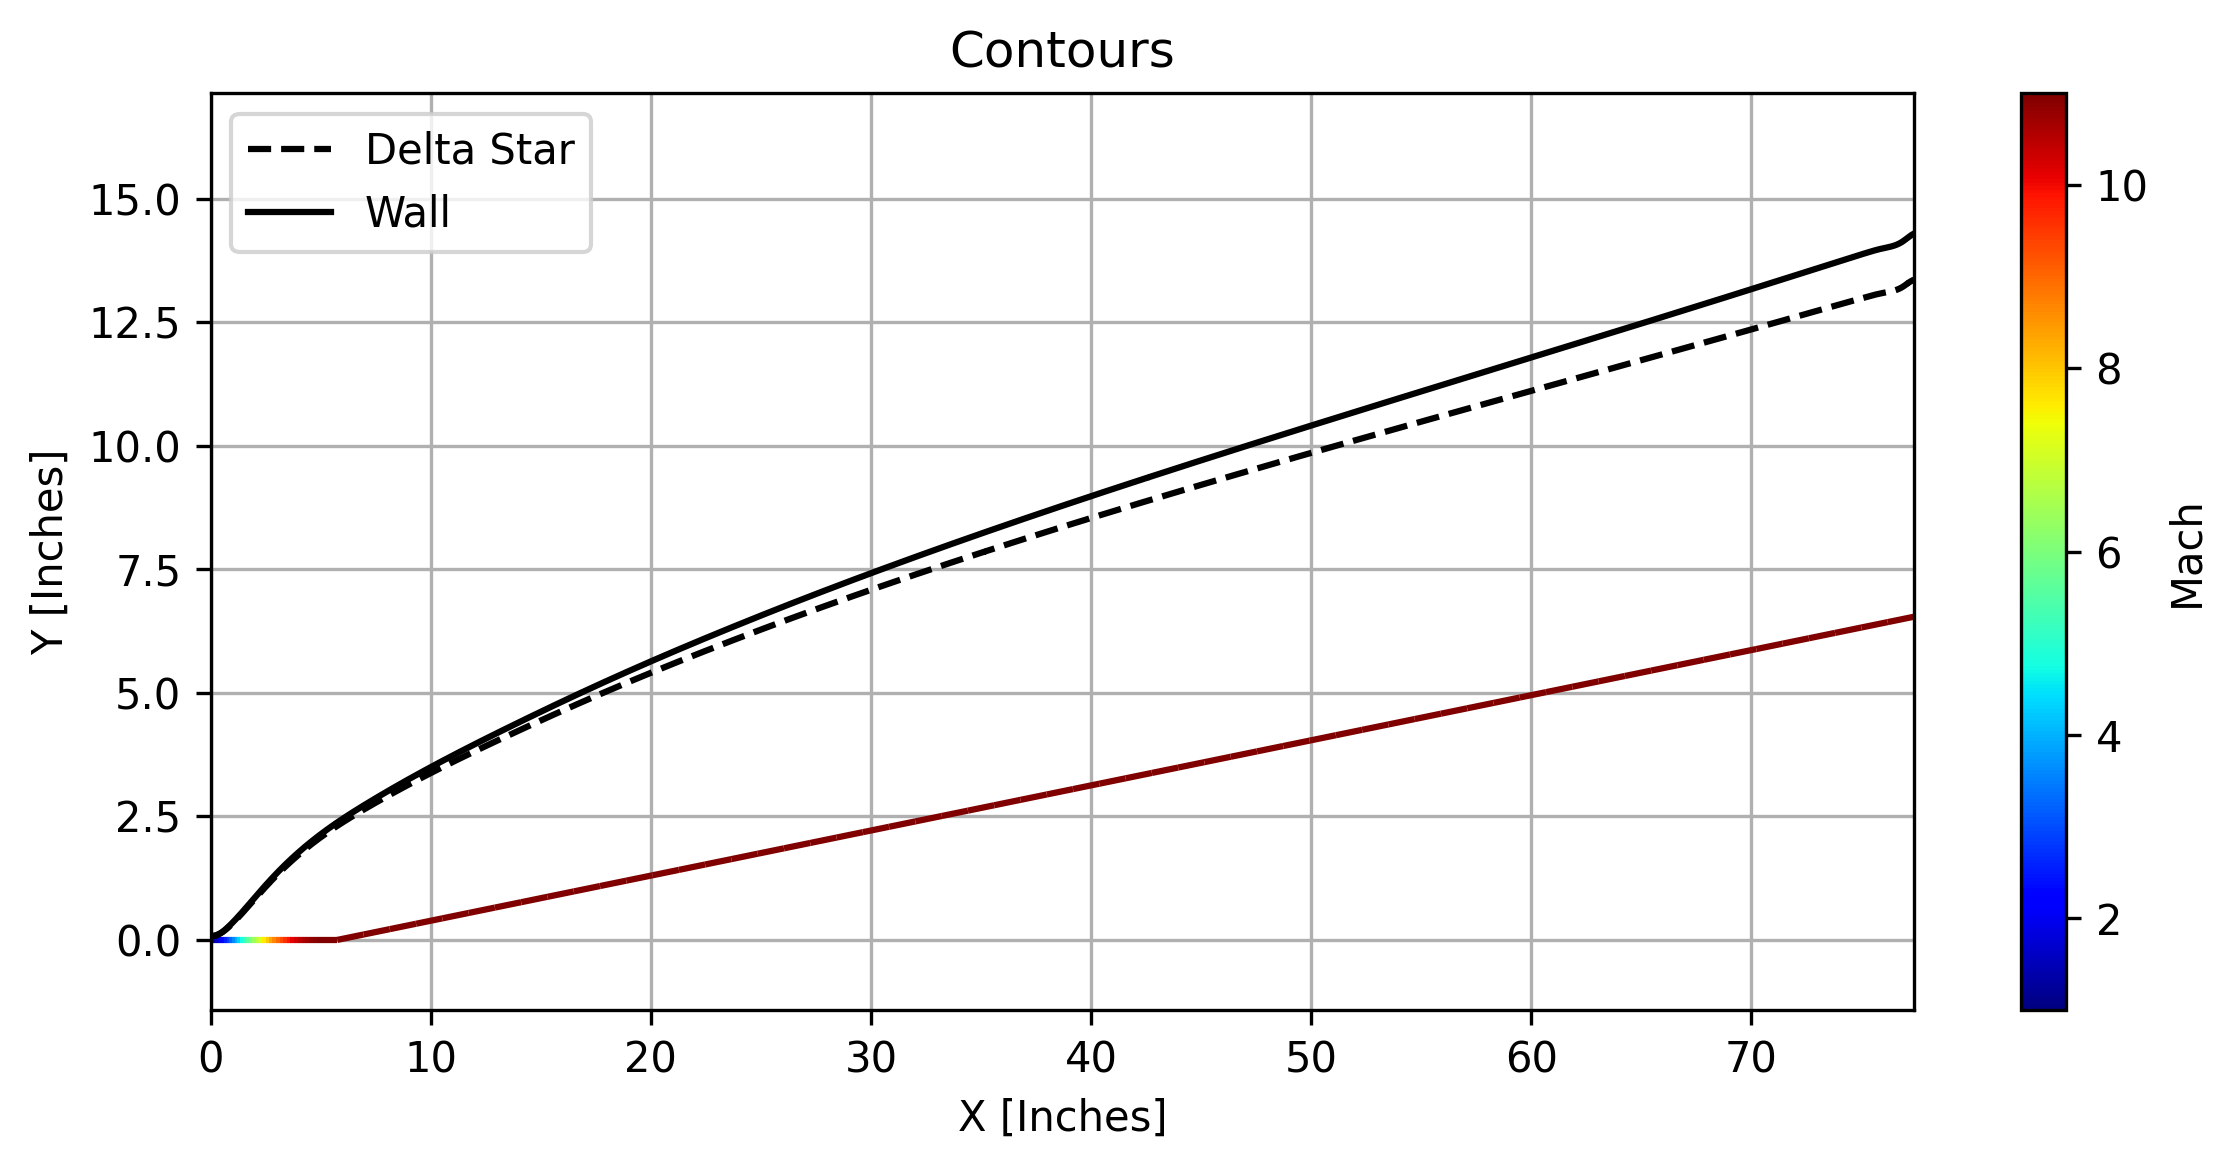

In [41]:
from IPython.display import display
from conturpy import gen_bl_thickness_plot, gen_bl_temperature_plot, gen_noz_characteristics, gen_throat_characteristics, gen_contours, gen_flow_angles, gen_flow_angles_throat
#plot_fns = [gen_bl_thickness_plot, gen_bl_temperature_plot, gen_noz_characteristics, gen_throat_characteristics, gen_contours, gen_flow_angles, gen_flow_angles_throat]
plot_fns = [gen_contours]

figs = []

for r in res:
    for plot_fn in plot_fns:
        f, ax = plot_fn(r)
        figs.append(f)

for f in figs:
    display(f)
    plt.close(f)